In [1]:
#import the libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

#Load Dataset
walmart = pd.read_csv("walmart_data.csv")
walmart.head()

,User_ID,Product_ID,Gender,Age,Occupation,City_Category,Stay_In_Current_City_Years,Marital_Status,Product_Category,Purchase
0,1000001,P00069042,F,0-17,10.0,A,2,0.0,3.0,8370.0
1,1000001,P00248942,F,0-17,10.0,A,2,0.0,1.0,15200.0
2,1000001,P00087842,F,0-17,10.0,A,2,0.0,12.0,1422.0
3,1000001,P00085442,F,0-17,10.0,A,2,0.0,12.0,1057.0
4,1000002,P00285442,M,55+,16.0,C,4+,0.0,8.0,7969.0


In [6]:
#Question 5: CLT & Confidence Intervals

#CLT Function
def apply_clt(data, iterations=1000, sample_size=1000):
    sample_means = []
    for _ in range(iterations):
        sample = data.sample(sample_size, replace=True)
        sample_means.append(sample.mean())
    return sample_means


In [7]:
#Male vs Female Analysis
male_spends = walmart[walmart['Gender'] == 'M']['Purchase']
female_spends = walmart[walmart['Gender'] == 'F']['Purchase']

male_means = apply_clt(male_spends)
female_means = apply_clt(female_spends)

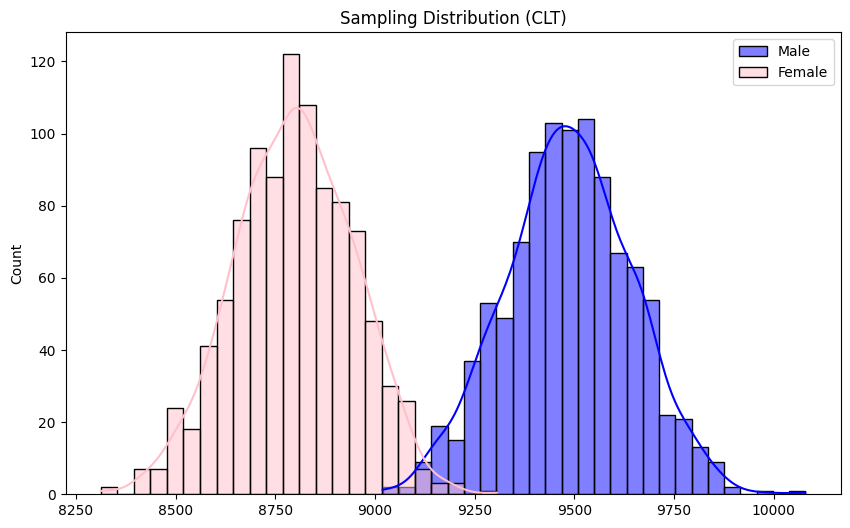

User_ID                          int64
Product_ID                      object
Gender                        category
Age                           category
Occupation                     float64
City_Category                 category
Stay_In_Current_City_Years    category
Marital_Status                category
Product_Category               float64
Purchase                       float64
dtype: object


In [8]:
#Plot Sampling Distribution
plt.figure(figsize=(10,6))
sns.histplot(male_means, color='blue', kde=True, label='Male')
sns.histplot(female_means, color='pink', kde=True, label='Female')
plt.legend()
plt.title("Sampling Distribution (CLT)")
plt.show()

print(walmart.dtypes)

In [9]:
#95% Confidence Interval
def get_95_ci(sample_means):
    mean = np.mean(sample_means)
    std_err = stats.sem(sample_means)
    return mean - 1.96*std_err, mean + 1.96*std_err

male_ci = get_95_ci(male_means)
female_ci = get_95_ci(female_means)

print("Male 95% CI:", male_ci)
print("Female 95% CI:", female_ci)

Male 95% CI: (np.float64(9476.354659157929), np.float64(9495.893207096327))
Female 95% CI: (np.float64(8788.153912070948), np.float64(8806.674717929052))


In [10]:
#Married vs Unmarried
married = walmart[walmart['Marital_Status'] == 1]['Purchase']
unmarried = walmart[walmart['Marital_Status'] == 0]['Purchase']

married_ci = get_95_ci(apply_clt(married))
unmarried_ci = get_95_ci(apply_clt(unmarried))

print("Married CI:", married_ci)
print("Unmarried CI:", unmarried_ci)

Married CI: (np.float64(9323.61241842381), np.float64(9342.55193357619))
Unmarried CI: (np.float64(9299.592607242721), np.float64(9319.383036757281))


In [11]:
#Age Analysis Example (26–35 vs 55+)
age_26_35 = walmart[walmart['Age'] == '26-35']['Purchase']
age_55_plus = walmart[walmart['Age'] == '55+']['Purchase']

print("26-35 CI:", get_95_ci(apply_clt(age_26_35)))
print("55+ CI:", get_95_ci(apply_clt(age_55_plus)))

26-35 CI: (np.float64(9303.232742693399), np.float64(9322.974581306604))
55+ CI: (np.float64(9413.73599553172), np.float64(9432.93110846828))
